# Preprocesado y Feature Engineering

En este notebook transformamos el dataset saneado (`data_sanitized.csv`) de transacciones individuales en una **serie temporal diaria** lista para ser modelizada, enriqueciéndola mediante ingeniería de variables.

El notebook es **autosuficiente**: carga el CSV desde disco sin depender de ningún notebook previo.

Las etapas que se realizan son:
- **4.1** Agregación diaria y creación de la variable objetivo `Ventas`
- **4.2** Variables categóricas de resumen diario (producto top, país top, clientes únicos)
- **4.3** Extracción de variables temporales desde la fecha
- **4.4** Análisis y limpieza de las nuevas variables
- **4.6** Análisis de correlación y selección de variables
- **4.7** Lags (retrasos temporales)
- **4.8** Medias móviles
- **4.9** Eventos especiales
- **4.10** Escalado y exportación (train/test split + CSV)


## 0. Imports y Carga del Dataset

Preparamos el entorno de trabajo: importamos librerías, configuramos la estética visual y definimos las rutas del proyecto.

A continuación cargamos `data_sanitized.csv` — el CSV limpio exportado por el notebook de limpieza — que ya incluye las columnas auxiliares `Fecha`, `Mes`, `DiaSemana`, `EsCancelacion` y `TotalPrice`, por lo que no es necesario recalcularlas.

Se inicializa también el diccionario de auditoría `stats_preprocesing` que registrará las transformaciones realizadas en este notebook.


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Configuración visual global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
%matplotlib inline

# Rutas del proyecto
RUTA_INTERIM   = '../../../data/interim/'
RUTA_GRAFICOS  = '../../../graphics/'
RUTA_PROCESSED = '../../../data/processed/'
os.makedirs(RUTA_GRAFICOS,  exist_ok=True)
os.makedirs(RUTA_PROCESSED, exist_ok=True)

print('Librerías cargadas correctamente.')


Librerías cargadas correctamente.


In [4]:
# Carga del CSV limpio (output del notebook de limpieza)
df_raw     = pd.read_csv(
    RUTA_INTERIM + 'data_sanitized.csv',
    parse_dates=['InvoiceDate', 'Fecha']
)
df_working = df_raw.copy()

# EsCancelacion puede llegar como string 'True'/'False' → forzar a bool
df_working['EsCancelacion'] = df_working['EsCancelacion'].astype(bool)

# Diccionario de auditoría (se actualiza en cada paso de transformación)
stats_preprocesing = {
    'Registros de entrada (transacciones)': len(df_raw),
}

# ── Resumen de carga ──────────────────────────────────────────────────────────
print('=' * 58)
print(f'  DATASET CARGADO  (data_sanitized.csv)')
print('=' * 58)
print(f'  Filas    : {df_raw.shape[0]:>10,}')
print(f'  Columnas : {df_raw.shape[1]:>10}')
print(f'  Rango    : {df_raw["Fecha"].min().date()} → {df_raw["Fecha"].max().date()}')
print('=' * 58)
print(f'\n  df_working activo : {len(df_working):,} filas')
print(f'  Columnas heredadas del notebook de limpieza:')
print(f'    - Fecha, Mes, DiaSemana, EsCancelacion, TotalPrice')
print(f'\n  Columnas completas: {list(df_working.columns)}')


  DATASET CARGADO  (data_sanitized.csv)
  Filas    :    531,172
  Columnas :         13
  Rango    : 2010-12-01 → 2011-12-09

  df_working activo : 531,172 filas
  Columnas heredadas del notebook de limpieza:
    - Fecha, Mes, DiaSemana, EsCancelacion, TotalPrice

  Columnas completas: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Fecha', 'Mes', 'DiaSemana', 'EsCancelacion', 'TotalPrice']


# 4. TRANSFORMACIÓN DE DATOS


### 4.1 Agregación diaria y creación de la variable objetivo "Ventas"

El dataset limpio tiene una fila por transacción de producto. Aquí lo convertimos en una **serie temporal diaria** con las siguientes variables:

| Variable | Descripción |
|---|---|
| `Ventas` | Venta **neta** diaria en £ — incluye cancelaciones (TotalPrice negativo) que restan automáticamente |
| `NumTransacc` | Número de líneas de producto vendidas ese día (solo ventas, sin cancelaciones) |
| `NumPedidos` | Número de pedidos únicos (`InvoiceNo`) ese día |
| `NumClientes` | Número de clientes únicos (`CustomerID`) ese día |
| `UnidadesVendidas` | Total de unidades físicas vendidas ese día |

Tras el `groupby`, se hace **reindex al rango completo** de fechas rellenando con 0 los días sin actividad (festivos, fines de semana cerrados). Esto es crítico para que los lags y medias móviles sean temporalmente consistentes: sin reindex, el Lag1 de un lunes sería el viernes, no el domingo.


In [5]:
# 4.1 — Agregación diaria y creación de la variable objetivo 'Ventas'
n_ventas   = (df_working['EsCancelacion'] == False).sum()
n_cancelac = (df_working['EsCancelacion'] == True).sum()
print(f"── 4.1 Agregación diaria ──")
print(f"  Filas en df_working   : {len(df_working):,}")
print(f"    → Ventas reales     : {n_ventas:,}")
print(f"    → Cancelaciones     : {n_cancelac:,}")
print(f"  Decisión: Ventas = venta NETA (cancelaciones restan como TotalPrice negativo)")

# ── Venta neta diaria (incluye cancelaciones) ─────────────────────────────────
ventas_netas = (
    df_working
    .groupby('Fecha', sort=True)
    .agg(Ventas=('TotalPrice', 'sum'))
    .reset_index()
)

# ── Variables de volumen (solo filas de venta, no cancelaciones) ──────────────
df_solo_ventas = df_working[df_working['EsCancelacion'] == False]

features_volumen = (
    df_solo_ventas
    .groupby('Fecha', sort=True)
    .agg(
        NumTransacc      = ('TotalPrice', 'count'),
        NumPedidos       = ('InvoiceNo',  'nunique'),
        NumClientes      = ('CustomerID', 'nunique'),
        UnidadesVendidas = ('Quantity',   'sum'),
    )
    .reset_index()
)

# ── Merge y reindex al rango completo de fechas ───────────────────────────────
df_daily = ventas_netas.merge(features_volumen, on='Fecha', how='left')

rango_completo = pd.date_range(
    start=df_daily['Fecha'].min(),
    end=df_daily['Fecha'].max(),
    freq='D'
)

df_daily = (
    df_daily
    .set_index('Fecha')
    .reindex(rango_completo)
    .rename_axis('Fecha')
    .fillna(0)
    .reset_index()
)

stats_preprocesing['Días serie temporal']     = len(df_daily)
stats_preprocesing['Días con ventas > 0']     = int((df_daily['Ventas'] > 0).sum())
stats_preprocesing['Días sin actividad (0)']  = int((df_daily['Ventas'] == 0).sum())


── 4.1 Agregación diaria ──
  Filas en df_working   : 531,172
    → Ventas reales     : 522,504
    → Cancelaciones     : 8,668
  Decisión: Ventas = venta NETA (cancelaciones restan como TotalPrice negativo)


In [6]:
# 4.1 — Verificación y resumen del dataframe diario
print(f"  Rango temporal             : {df_daily['Fecha'].min().date()} → {df_daily['Fecha'].max().date()}")
print(f"  Días en el rango completo  : {len(rango_completo)}")
print(f"  Días con Ventas > 0        : {(df_daily['Ventas'] > 0).sum()}")
print(f"  Días con Ventas = 0 (hueco): {(df_daily['Ventas'] == 0).sum()}")
print(f"  Días con Ventas < 0        : {(df_daily['Ventas'] < 0).sum()}  (devoluciones > ventas ese día)")
print(f"\n  Columnas del dataframe diario: {list(df_daily.columns)}")
print(f"\n  Primeras filas:")
print(df_daily.head(10).to_string(index=False))
print(f"\n  Estadísticas de 'Ventas' (£) — venta neta diaria:")
print(df_daily['Ventas'].describe().apply(lambda x: f"    {x:>12,.2f}").to_string())
print(f"\n  ✓ df_daily creado con {len(df_daily)} filas. Listo para las transformaciones siguientes.")


  Rango temporal             : 2010-12-01 → 2011-12-09
  Días en el rango completo  : 374
  Días con Ventas > 0        : 305
  Días con Ventas = 0 (hueco): 69
  Días con Ventas < 0        : 0  (devoluciones > ventas ese día)

  Columnas del dataframe diario: ['Fecha', 'Ventas', 'NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas']

  Primeras filas:
     Fecha   Ventas  NumTransacc  NumPedidos  NumClientes  UnidadesVendidas
2010-12-01 51118.57       3020.0       127.0         95.0           23464.0
2010-12-02 40795.79       2020.0       141.0         98.0           22960.0
2010-12-03 41801.33       2123.0        68.0         50.0           14596.0
2010-12-04     0.00          0.0         0.0          0.0               0.0
2010-12-05 29650.64       2591.0        88.0         75.0           14939.0
2010-12-06 47492.93       3757.0       102.0         82.0           20048.0
2010-12-07 57696.38       2835.0        82.0         65.0           18424.0
2010-12-08 40935.64       2519

### 4.2 Creación de variables categóricas de resumen diario

Para cada día calculamos dos variables categóricas a partir de las transacciones de venta (excluidas las cancelaciones):

| Variable | Descripción |
|---|---|
| `ProductoTopDia` | `StockCode` del producto con mayor `Quantity` vendida ese día |
| `PaisTopDia` | País con más líneas de pedido ese día |

Los días sin actividad (Ventas = 0 tras el reindex) reciben el valor `'Sin_Actividad'`.

> **Nota**: `PaisTopDia` se crea aquí pero será analizada en el 4.6 — el análisis de correlación determinará si aporta información al modelo o si tiene varianza ≈ 0 (UK domina el 100% de días activos).


In [7]:
# 4.2 — Variables categóricas de resumen diario
print("── 4.2 Variables categóricas de resumen diario ──")

# Producto con mayor Quantity vendida por día
producto_top = (
    df_solo_ventas
    .groupby(['Fecha', 'StockCode'], sort=False)['Quantity']
    .sum()
    .reset_index()
    .sort_values(['Fecha', 'Quantity'], ascending=[True, False])
    .groupby('Fecha', sort=True)
    .first()                          # primera fila por fecha = mayor Quantity
    .rename(columns={'StockCode': 'ProductoTopDia'})
    [['ProductoTopDia']]
    .reset_index()
)

# País con más líneas de pedido por día
pais_top = (
    df_solo_ventas
    .groupby(['Fecha', 'Country'], sort=False)['InvoiceNo']
    .count()
    .reset_index()
    .sort_values(['Fecha', 'InvoiceNo'], ascending=[True, False])
    .groupby('Fecha', sort=True)
    .first()
    .rename(columns={'Country': 'PaisTopDia'})
    [['PaisTopDia']]
    .reset_index()
)

# Merge con df_daily — los días sin actividad quedan como NaN → 'Sin_Actividad'
df_daily = (
    df_daily
    .merge(producto_top, on='Fecha', how='left')
    .merge(pais_top,     on='Fecha', how='left')
)
df_daily['ProductoTopDia'] = df_daily['ProductoTopDia'].fillna('Sin_Actividad')
df_daily['PaisTopDia']     = df_daily['PaisTopDia'].fillna('Sin_Actividad')

stats_preprocesing['Variables categóricas añadidas'] = ['ProductoTopDia', 'PaisTopDia']


── 4.2 Variables categóricas de resumen diario ──


In [8]:
# 4.2 — Verificación
print(f"  Columnas tras 4.2: {list(df_daily.columns)}")
print(f"\n  Días sin actividad (categóricas = 'Sin_Actividad'): "
      f"{(df_daily['ProductoTopDia'] == 'Sin_Actividad').sum()}")

print(f"\n  Top 10 productos más frecuentes como 'ProductoTopDia':")
print(df_daily['ProductoTopDia'].value_counts().head(10).to_string())

print(f"\n  Top 10 países más frecuentes como 'PaisTopDia':")
print(df_daily['PaisTopDia'].value_counts().head(10).to_string())

print(f"\n  Primeras filas con nuevas columnas:")
print(df_daily[['Fecha', 'Ventas', 'ProductoTopDia', 'PaisTopDia']].head(10).to_string(index=False))
print(f"\n  ✓ Variables categóricas añadidas a df_daily.")


  Columnas tras 4.2: ['Fecha', 'Ventas', 'NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas', 'ProductoTopDia', 'PaisTopDia']

  Días sin actividad (categóricas = 'Sin_Actividad'): 69

  Top 10 productos más frecuentes como 'ProductoTopDia':
ProductoTopDia
Sin_Actividad    69
85099B           40
23084            26
22197            22
84077            14
85123A           13
21212            10
84879            10
23203             8
47566             7

  Top 10 países más frecuentes como 'PaisTopDia':
PaisTopDia
United Kingdom    305
Sin_Actividad      69

  Primeras filas con nuevas columnas:
     Fecha   Ventas ProductoTopDia     PaisTopDia
2010-12-01 51118.57         85099B United Kingdom
2010-12-02 40795.79          21212 United Kingdom
2010-12-03 41801.33          21212 United Kingdom
2010-12-04     0.00  Sin_Actividad  Sin_Actividad
2010-12-05 29650.64          22867 United Kingdom
2010-12-06 47492.93          84946 United Kingdom
2010-12-07 57696.38         85123A Un

### 4.3 Extracción de variables temporales desde la fecha

De la columna `Fecha` extraemos 7 variables temporales que capturan la estacionalidad a distintas escalas:

| Variable | Rango | Descripción |
|---|---|---|
| `DiaSemana` | 0–6 | Día de la semana (0=Lunes, 6=Domingo) |
| `EsFinDeSemana` | 0–1 | 1 si sábado o domingo |
| `Mes` | 1–12 | Mes del año |
| `Trimestre` | 1–4 | Trimestre del año |
| `SemanaMes` | 1–5 | Semana dentro del mes (1ª, 2ª, … 5ª) |
| `DiaAnio` | 1–365 | Día del año (captura tendencia intra-anual) |
| `SemanaAnio` | 1–53 | Semana ISO del año |

`DiaSemana` se mantiene como entero en este punto. La decisión de aplicar One-Hot Encoding (necesaria para modelos lineales) o dejarlo numérico (válido para árboles) se tomará en cada notebook de modelo según corresponda.


In [9]:
# 4.3 — Extracción de variables temporales desde la fecha
print("── 4.3 Extracción de variables temporales desde la fecha ──")

df_daily['DiaSemana']     = df_daily['Fecha'].dt.dayofweek                    # 0=Lun, 6=Dom
df_daily['EsFinDeSemana'] = df_daily['Fecha'].dt.dayofweek.isin([5, 6]).astype(int)
df_daily['Mes']           = df_daily['Fecha'].dt.month                        # 1–12
df_daily['Trimestre']     = df_daily['Fecha'].dt.quarter                      # 1–4
df_daily['SemanaMes']     = df_daily['Fecha'].dt.day.apply(
                                lambda d: min((d - 1) // 7 + 1, 5)           # 1–5
                            )
df_daily['DiaAnio']       = df_daily['Fecha'].dt.dayofyear                    # 1–365
df_daily['SemanaAnio']    = df_daily['Fecha'].dt.isocalendar().week.astype(int)  # 1–53

nuevas_cols = ['DiaSemana', 'EsFinDeSemana', 'Mes', 'Trimestre',
               'SemanaMes', 'DiaAnio', 'SemanaAnio']
stats_preprocesing['Variables temporales añadidas'] = nuevas_cols


── 4.3 Extracción de variables temporales desde la fecha ──


In [10]:
# 4.3 — Verificación
print(f"  Columnas temporales añadidas : {nuevas_cols}")
print(f"  Columnas totales en df_daily : {list(df_daily.columns)}")

print(f"\n  Distribución de días por DiaSemana (0=Lun … 6=Dom):")
print(df_daily['DiaSemana'].value_counts().sort_index().to_string())

print(f"\n  Días marcados como fin de semana (EsFinDeSemana=1): "
      f"{df_daily['EsFinDeSemana'].sum()}")

print(f"\n  Distribución de días por Mes:")
print(df_daily['Mes'].value_counts().sort_index().to_string())

print(f"\n  Distribución de días por Trimestre:")
print(df_daily['Trimestre'].value_counts().sort_index().to_string())

print(f"\n  Primeras filas con variables temporales:")
cols_muestra = ['Fecha', 'Ventas', 'DiaSemana', 'EsFinDeSemana',
                'Mes', 'Trimestre', 'SemanaMes', 'SemanaAnio']
print(df_daily[cols_muestra].head(10).to_string(index=False))
print(f"\n  ✓ Variables temporales extraídas y añadidas a df_daily.")


  Columnas temporales añadidas : ['DiaSemana', 'EsFinDeSemana', 'Mes', 'Trimestre', 'SemanaMes', 'DiaAnio', 'SemanaAnio']
  Columnas totales en df_daily : ['Fecha', 'Ventas', 'NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas', 'ProductoTopDia', 'PaisTopDia', 'DiaSemana', 'EsFinDeSemana', 'Mes', 'Trimestre', 'SemanaMes', 'DiaAnio', 'SemanaAnio']

  Distribución de días por DiaSemana (0=Lun … 6=Dom):
DiaSemana
0    53
1    53
2    54
3    54
4    54
5    53
6    53

  Días marcados como fin de semana (EsFinDeSemana=1): 106

  Distribución de días por Mes:
Mes
1     31
2     28
3     31
4     30
5     31
6     30
7     31
8     31
9     30
10    31
11    30
12    40

  Distribución de días por Trimestre:
Trimestre
1     90
2     91
3     92
4    101

  Primeras filas con variables temporales:
     Fecha   Ventas  DiaSemana  EsFinDeSemana  Mes  Trimestre  SemanaMes  SemanaAnio
2010-12-01 51118.57          2              0   12          4          1          48
2010-12-02 40795.

### 4.4 Análisis y limpieza de las nuevas variables creadas

Detectamos y tratamos outliers o anomalías en las columnas generadas en los pasos anteriores. El análisis se divide en:

- **4.4.1** Outliers en variables numéricas (método IQR, sobre días activos)
- **4.4.2** Boxplots de las 5 variables de volumen
- **4.4.3** Verificación de rangos de variables temporales
- **4.4.4** Análisis de variables categóricas (`ProductoTopDia`, `PaisTopDia`)
- **4.4.5** Decisión razonada sobre el tratamiento de outliers


In [12]:
# 4.4.1 — Outliers en variables numéricas (método IQR, días activos)
print("── 4.4 Análisis y limpieza de las nuevas variables ──")
print("\n  -- 4.4.1 Outliers en variables numéricas (método IQR, días activos) --")

cols_numericas = ['Ventas', 'NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas']
df_activos     = df_daily[df_daily['Ventas'] > 0].copy()
fechas_outlier = {}

print(f"  Nota: se excluyen los {(df_daily['Ventas'] == 0).sum()} días sin actividad "
      f"(Ventas=0) para no distorsionar el IQR\n")

for col in cols_numericas:
    q1       = df_activos[col].quantile(0.25)
    q3       = df_activos[col].quantile(0.75)
    iqr      = q3 - q1
    lim_inf  = q1 - 1.5 * iqr
    lim_sup  = q3 + 1.5 * iqr
    mask_out = (df_activos[col] > lim_sup) | (df_activos[col] < lim_inf)
    n_out_sup = (df_activos[col] > lim_sup).sum()
    n_out_inf = (df_activos[col] < lim_inf).sum()
    fechas_outlier[col] = df_activos.loc[mask_out, 'Fecha'].dt.date.tolist()

    print(f"  {col}:")
    print(f"    Q1={q1:>10,.2f}  Q3={q3:>10,.2f}  IQR={iqr:>10,.2f}")
    print(f"    Límite inf={lim_inf:>10,.2f}  Límite sup={lim_sup:>10,.2f}")
    print(f"    Outliers superiores: {n_out_sup:>3}  |  Outliers inferiores: {n_out_inf:>3}")
    if fechas_outlier[col]:
        print(f"    Fechas afectadas: {fechas_outlier[col]}")
    print()


── 4.4 Análisis y limpieza de las nuevas variables ──

  -- 4.4.1 Outliers en variables numéricas (método IQR, días activos) --
  Nota: se excluyen los 69 días sin actividad (Ventas=0) para no distorsionar el IQR

  Ventas:
    Q1= 19,522.37  Q3= 36,287.29  IQR= 16,764.92
    Límite inf= -5,625.01  Límite sup= 61,434.67
    Outliers superiores:   6  |  Outliers inferiores:   0
    Fechas afectadas: [datetime.date(2011, 11, 10), datetime.date(2011, 11, 14), datetime.date(2011, 11, 23), datetime.date(2011, 11, 29), datetime.date(2011, 12, 5), datetime.date(2011, 12, 8)]

  NumTransacc:
    Q1=  1,179.00  Q3=  2,013.00  IQR=    834.00
    Límite inf=    -72.00  Límite sup=  3,264.00
    Outliers superiores:  16  |  Outliers inferiores:   0
    Fechas afectadas: [datetime.date(2010, 12, 6), datetime.date(2011, 10, 31), datetime.date(2011, 11, 6), datetime.date(2011, 11, 8), datetime.date(2011, 11, 11), datetime.date(2011, 11, 14), datetime.date(2011, 11, 15), datetime.date(2011, 11, 16), d

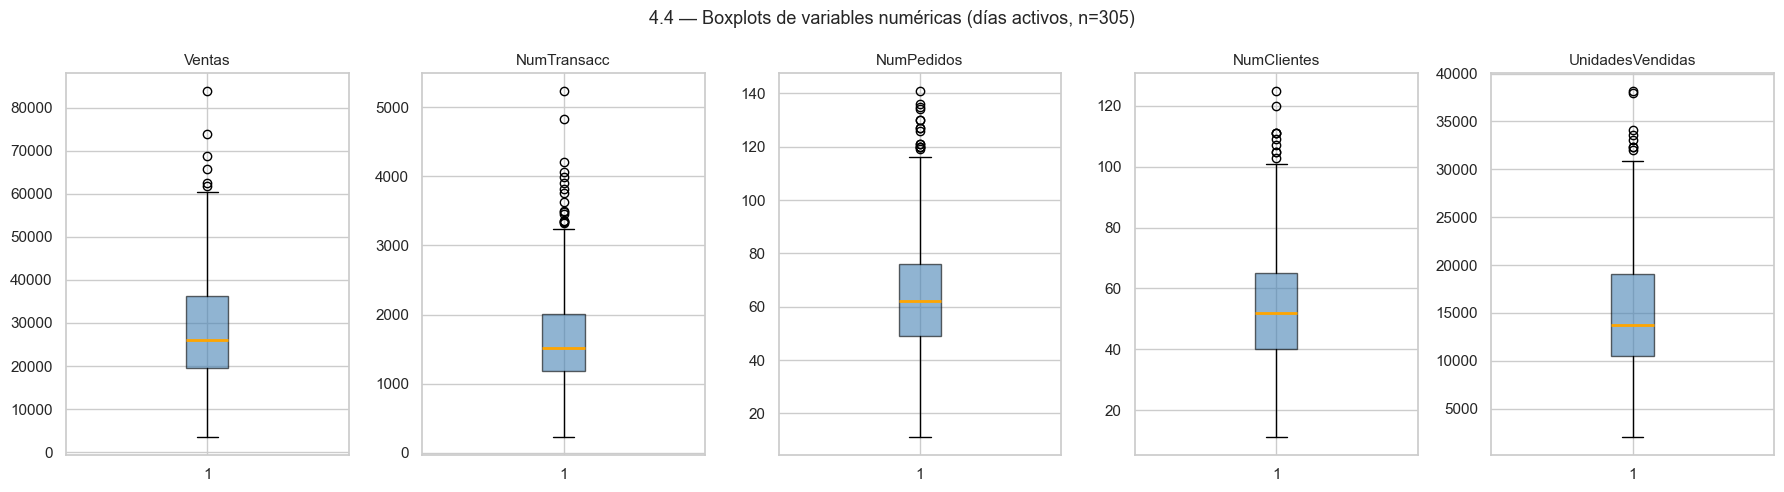

In [13]:
# 4.4.2 — Boxplots de variables numéricas
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, col in enumerate(cols_numericas):
    axes[i].boxplot(df_activos[col].values, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='orange', linewidth=2))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('')
fig.suptitle(f'4.4 — Boxplots de variables numéricas (días activos, n={len(df_activos)})',
             fontsize=13)
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}4.4_boxplots_variables_diarias.png', dpi=150)
plt.show()


In [14]:
# 4.4.3 — Verificar rangos de variables temporales
print("  -- 4.4.3 Verificación de rangos en variables temporales --")
rangos_esperados = {
    'DiaSemana':     (0, 6),
    'EsFinDeSemana': (0, 1),
    'Mes':           (1, 12),
    'Trimestre':     (1, 4),
    'SemanaMes':     (1, 5),
    'DiaAnio':       (1, 366),
    'SemanaAnio':    (1, 53),
}
todo_ok = True
for col, (min_esp, max_esp) in rangos_esperados.items():
    min_real = int(df_daily[col].min())
    max_real = int(df_daily[col].max())
    ok = min_real >= min_esp and max_real <= max_esp
    estado = '✓' if ok else '✗ FUERA DE RANGO'
    if not ok:
        todo_ok = False
    print(f"  {col:<16}: esperado [{min_esp:>3}, {max_esp:>3}]  →  real [{min_real:>3}, {max_real:>3}]  {estado}")
print(f"\n  {'✓ Todas las variables temporales dentro de rango esperado.' if todo_ok else '✗ Revisar columnas marcadas.'}")


  -- 4.4.3 Verificación de rangos en variables temporales --
  DiaSemana       : esperado [  0,   6]  →  real [  0,   6]  ✓
  EsFinDeSemana   : esperado [  0,   1]  →  real [  0,   1]  ✓
  Mes             : esperado [  1,  12]  →  real [  1,  12]  ✓
  Trimestre       : esperado [  1,   4]  →  real [  1,   4]  ✓
  SemanaMes       : esperado [  1,   5]  →  real [  1,   5]  ✓
  DiaAnio         : esperado [  1, 366]  →  real [  1, 365]  ✓
  SemanaAnio      : esperado [  1,  53]  →  real [  1,  52]  ✓

  ✓ Todas las variables temporales dentro de rango esperado.


In [15]:
# 4.4.4 — Análisis de variables categóricas
print("  -- 4.4.4 Análisis de variables categóricas --")

print("\n  ProductoTopDia — top 15 más frecuentes:")
freq_prod  = df_daily['ProductoTopDia'].value_counts()
raros_prod = freq_prod[(freq_prod <= 2) & (freq_prod.index != 'Sin_Actividad')]
print(freq_prod.head(15).to_string())
print(f"\n  Productos únicos (excl. Sin_Actividad): "
      f"{(freq_prod.index != 'Sin_Actividad').sum()}")
print(f"  Productos con ≤2 apariciones (raros): {len(raros_prod)}")
if len(raros_prod) > 0:
    print(f"  → Productos raros: {raros_prod.index.tolist()}")

print("\n  PaisTopDia — distribución completa:")
print(df_daily['PaisTopDia'].value_counts().to_string())
n_uk      = (df_daily['PaisTopDia'] == 'United Kingdom').sum()
n_activos = (df_daily['Ventas'] > 0).sum()
print(f"\n  'United Kingdom' domina {n_uk}/{n_activos} días activos "
      f"({n_uk/n_activos*100:.1f}%) → varianza prácticamente nula → se eliminará en 4.6")


  -- 4.4.4 Análisis de variables categóricas --

  ProductoTopDia — top 15 más frecuentes:
ProductoTopDia
Sin_Actividad    69
85099B           40
23084            26
22197            22
84077            14
85123A           13
21212            10
84879            10
23203             8
47566             7
71459             5
22178             5
22086             5
22834             4
20725             4

  Productos únicos (excl. Sin_Actividad): 109
  Productos con ≤2 apariciones (raros): 89
  → Productos raros: ['84946', '22355', '21985', '85099F', '17003', '21080', '22386', '84991', '22659', '23199', '22740', '84978', '22469', '22151', '16259', '22961', '23310', '75049L', '23209', '16045', '21181', '22952', '22065', '22867', '21844', '17012C', '70006', '84826', '22326', '82581', '20717', '21231', '72741', '22189', '21326', '21918', '22969', '20719', '22908', '21731', '21498', '21878', '22616', '22855', '22741', '20718', '85099C', '22294', '85093', '21749', '23077', '21398', '23207', '

In [16]:
# 4.4.5 — Decisión y conclusión sobre el tratamiento de outliers
print("  -- 4.4.5 Decisión sobre tratamiento de outliers --")
print("""
  Análisis realizado:
    · Los outliers en 'Ventas' y métricas de volumen corresponden a días
      de alta actividad real (pico pre-navideño, Black Friday 2011).
      No son errores de datos: el dataset de e-commerce tiene marcada
      estacionalidad en el Q4 (octubre–diciembre).
    · df_daily solo tiene ~374 filas (~305 activos) → eliminar filas
      empeoraría el modelo por pérdida de información crítica.
    · Capear 'Ventas' eliminaría la señal estacional que el modelo
      debe aprender a predecir.
    · Las variables de volumen (NumTransacc, NumPedidos, etc.) son
      proporcionales a Ventas; capear unas y no otras produce
      inconsistencias internas.
    · Las variables temporales están dentro de sus rangos esperados.
    · 'PaisTopDia' se marcará para eliminación en 4.6 (varianza ≈ 0).

  Decisión: NO se aplica capping ni eliminación en df_daily.
    → Los outliers son eventos reales que forman parte del patrón
      temporal que el modelo debe aprender.
    → Las ventanas rolling (4.8) y lags (4.7) incorporarán el contexto
      histórico y suavizarán la señal para el modelo.
""")
print(f"  ✓ df_daily sin cambios estructurales: {len(df_daily)} filas, "
      f"{len(df_daily.columns)} columnas.")


  -- 4.4.5 Decisión sobre tratamiento de outliers --

  Análisis realizado:
    · Los outliers en 'Ventas' y métricas de volumen corresponden a días
      de alta actividad real (pico pre-navideño, Black Friday 2011).
      No son errores de datos: el dataset de e-commerce tiene marcada
      estacionalidad en el Q4 (octubre–diciembre).
    · df_daily solo tiene ~374 filas (~305 activos) → eliminar filas
      empeoraría el modelo por pérdida de información crítica.
    · Capear 'Ventas' eliminaría la señal estacional que el modelo
      debe aprender a predecir.
    · Las variables de volumen (NumTransacc, NumPedidos, etc.) son
      proporcionales a Ventas; capear unas y no otras produce
      inconsistencias internas.
    · Las variables temporales están dentro de sus rangos esperados.
    · 'PaisTopDia' se marcará para eliminación en 4.6 (varianza ≈ 0).

  Decisión: NO se aplica capping ni eliminación en df_daily.
    → Los outliers son eventos reales que forman parte del patrón
  

### 4.5 Análisis de correlación y selección de variables

Antes de crear los lags y medias móviles analizamos qué variables tienen relación estadística con `Ventas` y detectamos redundancias entre ellas:

- **4.5.1** Correlación de Pearson de todas las variables numéricas con `Ventas`
- **4.5.2** Correlación de Spearman (más robusta ante outliers) — comparativa con Pearson
- **4.5.3** Heatmap de la matriz de correlación completa
- **4.5.4** Análisis de variables categóricas vs `Ventas`
- **4.5.5** Multicolinealidad entre variables de volumen
- **4.5.6** Decisión de variables a eliminar


In [17]:
# 4.5.1 — Correlación de Pearson con 'Ventas'
print("── 4.5 Análisis de correlación y selección de variables ──")
print("\n  -- 4.5.1 Correlación de Pearson con 'Ventas' (variables numéricas) --")
print("  Nota: se usan todos los días completos (incluye ceros de días inactivos)\n")

cols_correlacion = [
    'NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas',
    'DiaSemana', 'EsFinDeSemana', 'Mes', 'Trimestre',
    'SemanaMes', 'DiaAnio', 'SemanaAnio'
]

correlaciones = (
    df_daily[cols_correlacion + ['Ventas']]
    .corr()['Ventas']
    .drop('Ventas')
    .sort_values(key=abs, ascending=False)
)

print(f"  {'Variable':<20} {'Correlación':>12}  {'Interpretación'}")
print(f"  {'-'*60}")
for var, corr in correlaciones.items():
    if abs(corr) >= 0.5:
        nivel = 'Alta'
    elif abs(corr) >= 0.3:
        nivel = 'Moderada'
    elif abs(corr) >= 0.1:
        nivel = 'Baja'
    else:
        nivel = 'Muy baja / irrelevante'
    print(f"  {var:<20} {corr:>12.4f}  {nivel}")


── 4.5 Análisis de correlación y selección de variables ──

  -- 4.5.1 Correlación de Pearson con 'Ventas' (variables numéricas) --
  Nota: se usan todos los días completos (incluye ceros de días inactivos)

  Variable              Correlación  Interpretación
  ------------------------------------------------------------
  UnidadesVendidas           0.9731  Alta
  NumPedidos                 0.9112  Alta
  NumTransacc                0.9072  Alta
  NumClientes                0.8923  Alta
  EsFinDeSemana             -0.6079  Alta
  DiaSemana                 -0.4582  Moderada
  Mes                        0.3500  Moderada
  DiaAnio                    0.3434  Moderada
  Trimestre                  0.3410  Moderada
  SemanaAnio                 0.3273  Moderada
  SemanaMes                 -0.0974  Muy baja / irrelevante


In [18]:
# 4.5.2 — Correlación de Spearman (más robusta ante outliers)
print("  -- 4.5.2 Correlación de Spearman con 'Ventas' (más robusta ante outliers) --\n")

correlaciones_sp = (
    df_daily[cols_correlacion + ['Ventas']]
    .corr(method='spearman')['Ventas']
    .drop('Ventas')
    .sort_values(key=abs, ascending=False)
)

print(f"  {'Variable':<20} {'Pearson':>10} {'Spearman':>10}  {'Δ (abs)':>8}")
print(f"  {'-'*55}")
for var in correlaciones_sp.index:
    p  = correlaciones[var] if var in correlaciones.index else float('nan')
    sp = correlaciones_sp[var]
    print(f"  {var:<20} {p:>10.4f} {sp:>10.4f}  {abs(abs(sp)-abs(p)):>8.4f}")


  -- 4.5.2 Correlación de Spearman con 'Ventas' (más robusta ante outliers) --

  Variable                Pearson   Spearman   Δ (abs)
  -------------------------------------------------------
  UnidadesVendidas         0.9731     0.9747    0.0016
  NumTransacc              0.9072     0.9165    0.0093
  NumPedidos               0.9112     0.9115    0.0003
  NumClientes              0.8923     0.8776    0.0146
  EsFinDeSemana           -0.6079    -0.6206    0.0126
  DiaSemana               -0.4582    -0.4630    0.0048
  Mes                      0.3500     0.3346    0.0154
  Trimestre                0.3410     0.3288    0.0121
  DiaAnio                  0.3434     0.3259    0.0175
  SemanaAnio               0.3273     0.3089    0.0184
  SemanaMes               -0.0974    -0.0922    0.0052


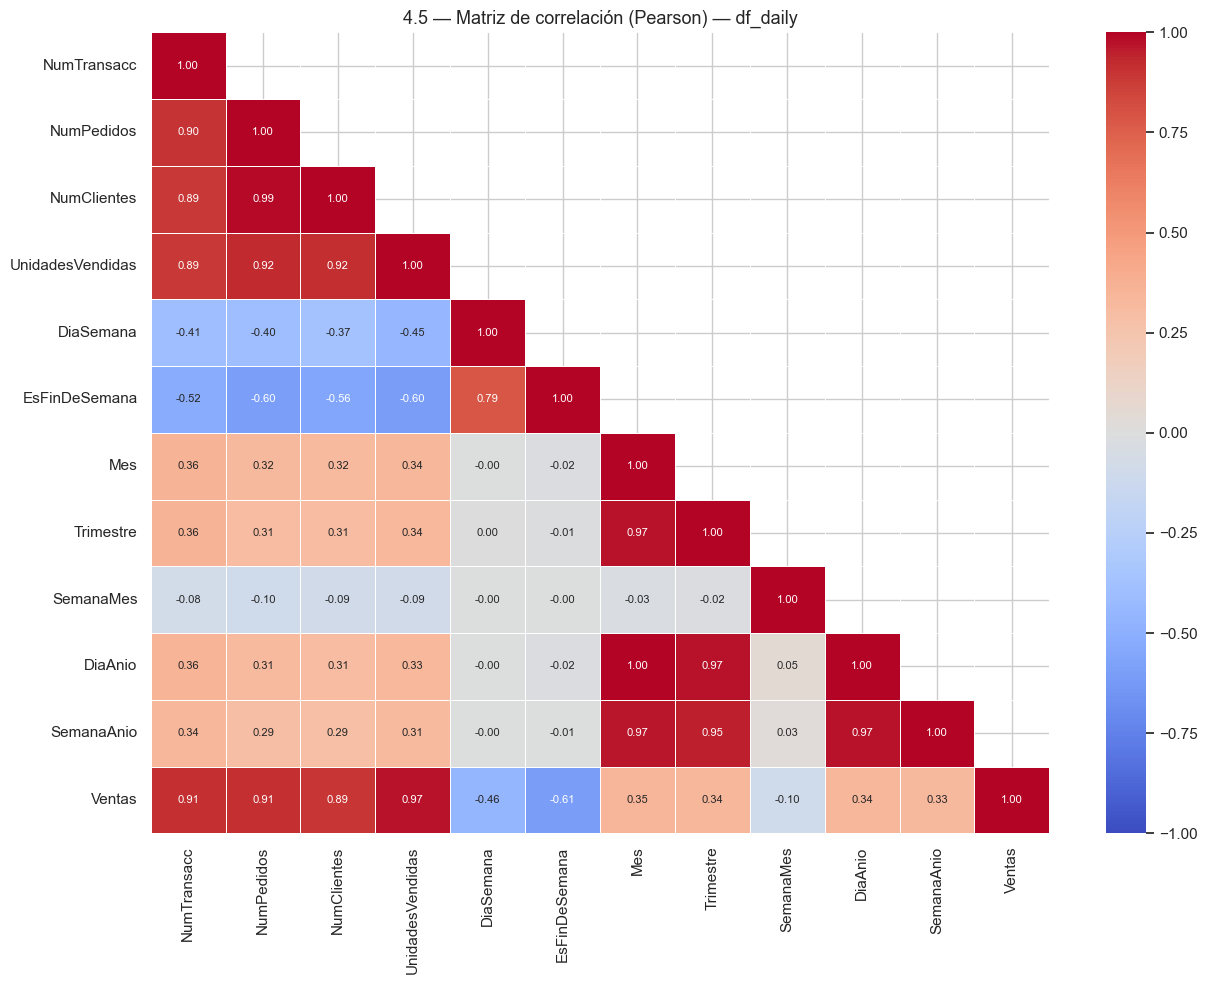

In [19]:
# 4.5.3 — Heatmap de correlaciones
cols_heatmap = cols_correlacion + ['Ventas']
corr_matrix  = df_daily[cols_heatmap].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mascara = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    mask=mascara,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title('4.5 — Matriz de correlación (Pearson) — df_daily', fontsize=13)
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}4.5_correlacion_heatmap.png', dpi=150)
plt.show()


In [20]:
# 4.5.4 — Análisis de variables categóricas vs Ventas
print("  -- 4.5.4 Varianza de PaisTopDia y ProductoTopDia vs Ventas --")

var_pais = df_daily['PaisTopDia'].nunique()
print(f"\n  PaisTopDia: {var_pais} valores únicos → varianza ≈ 0 → candidata a eliminar")

print(f"\n  Ventas media por ProductoTopDia (top 10 más frecuentes):")
media_prod = (
    df_daily[df_daily['ProductoTopDia'] != 'Sin_Actividad']
    .groupby('ProductoTopDia')['Ventas']
    .agg(['mean', 'count'])
    .sort_values('count', ascending=False)
    .head(10)
    .rename(columns={'mean': 'Ventas_Media', 'count': 'N_dias'})
)
print(media_prod.to_string())


  -- 4.5.4 Varianza de PaisTopDia y ProductoTopDia vs Ventas --

  PaisTopDia: 2 valores únicos → varianza ≈ 0 → candidata a eliminar

  Ventas media por ProductoTopDia (top 10 más frecuentes):
                Ventas_Media  N_dias
ProductoTopDia                      
85099B          31246.797000      40
23084           45267.575000      26
22197           33853.187273      22
84077           26337.017857      14
85123A          24570.100769      13
21212           32525.915000      10
84879           25316.220000      10
23203           26885.815000       8
47566           28942.911429       7
71459           22207.328000       5


In [21]:
# 4.5.5 — Multicolinealidad entre variables de volumen
print("  -- 4.5.5 Multicolinealidad entre variables de volumen --")
cols_volumen = ['NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas']
corr_vol = df_daily[cols_volumen].corr().round(3)
print(f"\n  Matriz de correlación entre variables de volumen:")
print(corr_vol.to_string())
print(f"\n  Nota: correlaciones muy altas (>0.95) indican redundancia.")


  -- 4.5.5 Multicolinealidad entre variables de volumen --

  Matriz de correlación entre variables de volumen:
                  NumTransacc  NumPedidos  NumClientes  UnidadesVendidas
NumTransacc             1.000       0.902        0.890             0.890
NumPedidos              0.902       1.000        0.989             0.925
NumClientes             0.890       0.989        1.000             0.919
UnidadesVendidas        0.890       0.925        0.919             1.000

  Nota: correlaciones muy altas (>0.95) indican redundancia.


In [22]:
# 4.5.6 — Decisión y variables descartadas
print("  -- 4.5.6 Decisión de selección de variables --")

VARS_ELIMINAR = ['PaisTopDia']

print(f"""
  Variables ELIMINADAS de df_daily:
    · PaisTopDia        → UK domina ~100% de días activos; varianza ≈ 0;
                          no aporta información al modelo.

  Variables CONSERVADAS con observaciones:
    · NumTransacc, NumPedidos, NumClientes, UnidadesVendidas
                        → Alta correlación con Ventas. Son redundantes entre sí
                          (multicolinealidad alta), pero se conservan todas ahora
                          y se dejará que los modelos con regularización (Ridge,
                          Lasso) las gestionen en la fase de modelado.
    · DiaAnio, SemanaAnio, Mes, Trimestre
                        → Capturan la tendencia y estacionalidad anual.
    · DiaSemana, EsFinDeSemana
                        → Capturan el patrón semanal (fines de semana = 0 ventas).
    · SemanaMes         → Correlación baja; se conserva por si aporta
                          señal en combinación con otras variables.
    · ProductoTopDia    → Se conserva; el encoding se hará en el bloque
                          de codificación (agrupando raros en 'Otros').
""")

df_daily = df_daily.drop(columns=VARS_ELIMINAR)
stats_preprocesing['Variables eliminadas (baja varianza)'] = VARS_ELIMINAR

print(f"  Columnas finales en df_daily ({len(df_daily.columns)} total):")
print(f"  {list(df_daily.columns)}")
print(f"\n  ✓ Selección de variables completada. df_daily listo para lags y rolling windows.")


  -- 4.5.6 Decisión de selección de variables --

  Variables ELIMINADAS de df_daily:
    · PaisTopDia        → UK domina ~100% de días activos; varianza ≈ 0;
                          no aporta información al modelo.

  Variables CONSERVADAS con observaciones:
    · NumTransacc, NumPedidos, NumClientes, UnidadesVendidas
                        → Alta correlación con Ventas. Son redundantes entre sí
                          (multicolinealidad alta), pero se conservan todas ahora
                          y se dejará que los modelos con regularización (Ridge,
                          Lasso) las gestionen en la fase de modelado.
    · DiaAnio, SemanaAnio, Mes, Trimestre
                        → Capturan la tendencia y estacionalidad anual.
    · DiaSemana, EsFinDeSemana
                        → Capturan el patrón semanal (fines de semana = 0 ventas).
    · SemanaMes         → Correlación baja; se conserva por si aporta
                          señal en combinación con otras variable

### 4.6 Lags (retrasos temporales)

Los **lags** permiten al modelo usar las ventas de días anteriores como predictores del día actual, capturando la autocorrelación de la serie temporal:

| Variable | Descripción |
|---|---|
| `Ventas_Lag1` | Ventas del día anterior (t-1) |
| `Ventas_Lag7` | Ventas del mismo día de la semana pasada (t-7) |

Tras crear los lags se eliminan las primeras 7 filas (las únicas que tienen NaN) antes de calcular las medias móviles. Esto es correcto porque las medias móviles usan `min_periods=1` y no generan NaN adicionales, por lo que no tiene sentido retrasar el `dropna()`.


In [23]:
# 4.6 — Lags (retrasos temporales)
print("── 4.6 Lags (retrasos temporales) ──")

df_daily['Ventas_Lag1'] = df_daily['Ventas'].shift(1)
df_daily['Ventas_Lag7'] = df_daily['Ventas'].shift(7)

n_nan_lag1 = df_daily['Ventas_Lag1'].isna().sum()
n_nan_lag7 = df_daily['Ventas_Lag7'].isna().sum()

print(f"\n  Lag1 — NaN generados: {n_nan_lag1}  (fila 0: sin día anterior)")
print(f"  Lag7 — NaN generados: {n_nan_lag7}  (filas 0–6: sin semana anterior)")

print(f"\n  Primeras 10 filas con lags (observar NaN iniciales):")
cols_lag = ['Fecha', 'Ventas', 'Ventas_Lag1', 'Ventas_Lag7']
print(df_daily[cols_lag].head(10).to_string(index=False))

# ── Eliminar las primeras 7 filas con NaN — antes de las rolling windows ──────
filas_antes = len(df_daily)
df_daily = df_daily.dropna(subset=['Ventas_Lag1', 'Ventas_Lag7']).reset_index(drop=True)
filas_despues = len(df_daily)

print(f"\n  Filas antes del dropna : {filas_antes}")
print(f"  Filas eliminadas       : {filas_antes - filas_despues}  "
      f"(primera fila válida: {df_daily['Fecha'].min().date()})")
print(f"  Filas tras el dropna   : {filas_despues}")

stats_preprocesing['Filas eliminadas por lags (NaN iniciales)'] = filas_antes - filas_despues


── 4.6 Lags (retrasos temporales) ──

  Lag1 — NaN generados: 1  (fila 0: sin día anterior)
  Lag7 — NaN generados: 7  (filas 0–6: sin semana anterior)

  Primeras 10 filas con lags (observar NaN iniciales):
     Fecha   Ventas  Ventas_Lag1  Ventas_Lag7
2010-12-01 51118.57          NaN          NaN
2010-12-02 40795.79     51118.57          NaN
2010-12-03 41801.33     40795.79          NaN
2010-12-04     0.00     41801.33          NaN
2010-12-05 29650.64         0.00          NaN
2010-12-06 47492.93     29650.64          NaN
2010-12-07 57696.38     47492.93          NaN
2010-12-08 40935.64     57696.38     51118.57
2010-12-09 43420.95     40935.64     40795.79
2010-12-10 50741.62     43420.95     41801.33

  Filas antes del dropna : 374
  Filas eliminadas       : 7  (primera fila válida: 2010-12-08)
  Filas tras el dropna   : 367


In [24]:
# 4.6 — Validación de consistencia de los lags
print("  Validación — muestra de consistencia (Ventas_Lag1):")
idx_check = [10, 20, 50]
for i in idx_check:
    fecha_actual  = df_daily.loc[i, 'Fecha']
    ventas_actual = df_daily.loc[i, 'Ventas']
    lag1_almac    = df_daily.loc[i, 'Ventas_Lag1']
    ventas_ayer   = df_daily.loc[i - 1, 'Ventas']
    ok = '✓' if abs(lag1_almac - ventas_ayer) < 0.01 else '✗'
    print(f"  [{i}] {fecha_actual.date()}  Ventas={ventas_actual:>10,.2f}"
          f"  Lag1={lag1_almac:>10,.2f}  Ventas[i-1]={ventas_ayer:>10,.2f}  {ok}")

print(f"\n  Estadísticas de los lags:")
print(df_daily[['Ventas_Lag1', 'Ventas_Lag7']].describe()
      .map(lambda x: f"{x:>12,.2f}").to_string())

print(f"\n  Columnas en df_daily ({len(df_daily.columns)} total): {list(df_daily.columns)}")
print(f"\n  ✓ Lags añadidos. df_daily: {len(df_daily)} filas.")


  Validación — muestra de consistencia (Ventas_Lag1):
  [10] 2010-12-18  Ventas=      0.00  Lag1= 38,388.04  Ventas[i-1]= 38,388.04  ✓
  [20] 2010-12-28  Ventas=      0.00  Lag1=      0.00  Ventas[i-1]=      0.00  ✓
  [50] 2011-01-27  Ventas= 22,091.53  Lag1= 17,748.27  Ventas[i-1]= 17,748.27  ✓

  Estadísticas de los lags:
        Ventas_Lag1   Ventas_Lag7
count        367.00        367.00
mean      23,119.74     22,963.19
std       16,673.51     16,337.16
min            0.00          0.00
25%       11,034.26     11,034.26
50%       22,592.35     22,592.35
75%       32,536.19     32,536.19
max       83,931.62     83,931.62

  Columnas en df_daily (16 total): ['Fecha', 'Ventas', 'NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas', 'ProductoTopDia', 'DiaSemana', 'EsFinDeSemana', 'Mes', 'Trimestre', 'SemanaMes', 'DiaAnio', 'SemanaAnio', 'Ventas_Lag1', 'Ventas_Lag7']

  ✓ Lags añadidos. df_daily: 367 filas.


### 4.7 Medias móviles (rolling windows)

Las medias móviles suavizan los picos aislados y capturan la tendencia reciente:

| Variable | Cálculo | Descripción |
|---|---|---|
| `Ventas_Media_7d` | `shift(1).rolling(7).mean()` | Media de los 7 días **anteriores** al día t |
| `Ventas_Media_30d` | `shift(1).rolling(30).mean()` | Media de los 30 días **anteriores** al día t |

El `shift(1)` **antes** del `rolling` es crítico para evitar **data leakage**: sin él, la media del día t incluiría las ventas del propio día t, que es exactamente lo que el modelo tiene que predecir. Con `shift(1)` la ventana siempre termina en t-1.

`min_periods=1` permite calcular la media aunque no haya 7 o 30 días previos completos (inicio de la serie), evitando NaN adicionales.


In [25]:
# 4.7 — Medias móviles con shift(1) para evitar data leakage
print("── 4.7 Medias móviles (rolling windows) ──")

# shift(1) ANTES del rolling → la ventana usa solo días anteriores a t, nunca t
df_daily['Ventas_Media_7d']  = df_daily['Ventas'].shift(1).rolling(window=7,  min_periods=1).mean()
df_daily['Ventas_Media_30d'] = df_daily['Ventas'].shift(1).rolling(window=30, min_periods=1).mean()

n_nan_7d  = df_daily['Ventas_Media_7d'].isna().sum()
n_nan_30d = df_daily['Ventas_Media_30d'].isna().sum()
print(f"\n  NaN en Ventas_Media_7d  : {n_nan_7d}   (esperado: 0 con min_periods=1)")
print(f"  NaN en Ventas_Media_30d : {n_nan_30d}  (esperado: 0 con min_periods=1)")

print(f"\n  Primeras 12 filas con medias móviles:")
cols_roll = ['Fecha', 'Ventas', 'Ventas_Media_7d', 'Ventas_Media_30d']
print(df_daily[cols_roll].head(12).to_string(index=False))


── 4.7 Medias móviles (rolling windows) ──

  NaN en Ventas_Media_7d  : 1   (esperado: 0 con min_periods=1)
  NaN en Ventas_Media_30d : 1  (esperado: 0 con min_periods=1)

  Primeras 12 filas con medias móviles:
     Fecha   Ventas  Ventas_Media_7d  Ventas_Media_30d
2010-12-08 40935.64              NaN               NaN
2010-12-09 43420.95     40935.640000      40935.640000
2010-12-10 50741.62     42178.295000      42178.295000
2010-12-11     0.00     45032.736667      45032.736667
2010-12-12 16751.70     33774.552500      33774.552500
2010-12-13 34693.15     30369.982000      30369.982000
2010-12-14 40153.95     31090.510000      31090.510000
2010-12-15 26630.96     32385.287143      32385.287143
2010-12-16 38464.87     30341.761429      31665.996250
2010-12-17 38388.04     29633.750000      32421.426667
2010-12-18     0.00     27868.952857      33018.088000
2010-12-19  7034.15     27868.952857      30016.443636


In [26]:
# 4.7 — Validación manual: fila i debe tener Media_7d = media de Ventas[i-7 … i-1]
print("  Validación manual de Ventas_Media_7d en fila 10:")
media_manual = df_daily.loc[3:9, 'Ventas'].mean()   # filas i-7 a i-1  (shift + rolling 7)
media_stored = df_daily.loc[10, 'Ventas_Media_7d']
ok = '✓' if abs(media_manual - media_stored) < 0.01 else '✗'
print(f"  Media manual Ventas[3–9]: {media_manual:>12,.2f}")
print(f"  Valor almacenado [10]   : {media_stored:>12,.2f}  {ok}")

print(f"\n  Estadísticas de las medias móviles:")
print(df_daily[['Ventas_Media_7d', 'Ventas_Media_30d']].describe()
      .map(lambda x: f"{x:>12,.2f}").to_string())

stats_preprocesing['Medias móviles añadidas'] = ['Ventas_Media_7d (shift-1)', 'Ventas_Media_30d (shift-1)']


  Validación manual de Ventas_Media_7d en fila 10:
  Media manual Ventas[3–9]:    27,868.95
  Valor almacenado [10]   :    27,868.95  ✓

  Estadísticas de las medias móviles:
      Ventas_Media_7d Ventas_Media_30d
count          366.00           366.00
mean        22,904.83        22,476.80
std          9,394.71         7,568.70
min              0.00        11,085.42
25%         16,895.87        17,460.88
50%         20,755.61        19,942.52
75%         28,293.65        25,602.13
max         48,502.20        45,032.74


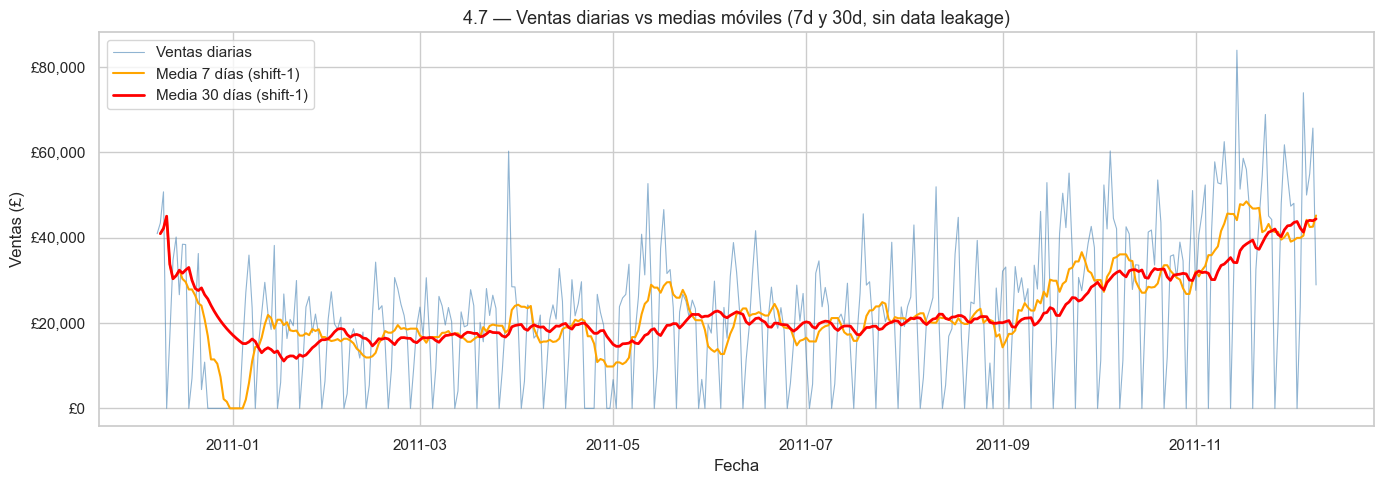


  Columnas en df_daily (18 total): ['Fecha', 'Ventas', 'NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas', 'ProductoTopDia', 'DiaSemana', 'EsFinDeSemana', 'Mes', 'Trimestre', 'SemanaMes', 'DiaAnio', 'SemanaAnio', 'Ventas_Lag1', 'Ventas_Lag7', 'Ventas_Media_7d', 'Ventas_Media_30d']

  ✓ Medias móviles añadidas. df_daily: 367 filas.


In [27]:
# 4.7 — Gráfica: Ventas vs medias móviles
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_daily['Fecha'], df_daily['Ventas'],
        color='steelblue', linewidth=0.8, alpha=0.6, label='Ventas diarias')
ax.plot(df_daily['Fecha'], df_daily['Ventas_Media_7d'],
        color='orange', linewidth=1.5, label='Media 7 días (shift-1)')
ax.plot(df_daily['Fecha'], df_daily['Ventas_Media_30d'],
        color='red', linewidth=2.0, label='Media 30 días (shift-1)')
ax.set_title('4.7 — Ventas diarias vs medias móviles (7d y 30d, sin data leakage)', fontsize=13)
ax.set_xlabel('Fecha')
ax.set_ylabel('Ventas (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}4.7_medias_moviles.png', dpi=150)
plt.show()

print(f"\n  Columnas en df_daily ({len(df_daily.columns)} total): {list(df_daily.columns)}")
print(f"\n  ✓ Medias móviles añadidas. df_daily: {len(df_daily)} filas.")


In [11]:
# [DOC] generamos variables temporales básicas, variables de memoria y ventanas móviles

# [DOC] Variables Temporales Básicas
df_daily_sales['DayOfWeek'] = df_daily_sales['Date'].dt.dayofweek
df_daily_sales['Month'] = df_daily_sales['Date'].dt.month
df_daily_sales['IsWeekend'] = df_daily_sales['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

# [DOC] Variables de Memoria (Lags)
# No solo el día anterior (Lag 1), sino el mismo día de la semana pasada (Lag 7)
df_daily_sales['Sales_Lag1'] = df_daily_sales['Sales'].shift(1)
df_daily_sales['Sales_Lag7'] = df_daily_sales['Sales'].shift(7)

# [DOC] Ventanas Móviles (Rolling Windows)
# Promedio de ventas de los últimos 7 días (suaviza picos aislados)
df_daily_sales['Rolling_Mean_7'] = df_daily_sales['Sales'].shift(1).rolling(window=7).mean()

df_daily_sales.dropna(inplace=True)

NameError: name 'df_daily_sales' is not defined

In [ ]:
# [DOC] Aplicamos One-Hot Encoding para el día de la semana y separamos el conjunto de entrenamiento y test antes de escalar

df_daily_sales = pd.get_dummies(df_daily_sales, columns=['DayOfWeek'], prefix='Day')

split_date = pd.to_datetime('2011-11-09')

df_train = df_daily_sales[df_daily_sales['Date'] < split_date].copy()
df_test = df_daily_sales[df_daily_sales['Date'] >= split_date].copy()

print(f"[INFO] Registros Entrenamiento: {len(df_train)}")
print(f"[INFO] Registros Test: {len(df_test)}")

In [ ]:
# [DOC] Escalamos las variables numéricas para que todas tengan el mismo peso en el modelo.

features_to_scale = ['Sales_Lag1', 'Sales_Lag7', 'Rolling_Mean_7', 'TransactionCount']
scaler = StandardScaler()

df_train[features_to_scale] = scaler.fit_transform(df_train[features_to_scale])
df_test[features_to_scale] = scaler.transform(df_test[features_to_scale])

In [ ]:
# [DOC] Realizamos el guardado de los datos procesados

output_dir = '../../data/processed'

if not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True)
    print(f"[INFO] Carpeta creada con éxito: {output_dir}")

df_train.to_csv(os.path.join(output_dir, 'train_data.csv'), index=False)
df_test.to_csv(os.path.join(output_dir, 'test_data.csv'), index=False)

print(f"[SUCCESS] Archivos guardados correctamente en: {output_dir}")
display(df_train.head())